<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week04/tanh_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motivation: a general percepron
- represented by a weight vector w and a bias b
- the training set consists of matrix: X (inputs) and vector d(true outputs)


In [160]:
import numpy as np
N = 4 # number of samples
n = 2 # number of features

# Perceptron:
w = np.random.uniform(-1,1,(n,1)) # weight vector (n,1)
b = np.random.uniform(-1,1,(1,1)) # bias  (1,1)

# Training set:
X = np.random.uniform(-1,1,(N,n)) # input matrix (N,n)
d = np.random.uniform(-1,1,(N,1)) # desired output vector (N,1)

print("w:", w, sep="\n")
print("b:", b, sep="\n")
print("X:", X, sep="\n")
print("d:", d, sep="\n")


w:
[[-0.57768611]
 [ 0.95781349]]
b:
[[0.94370967]]
X:
[[ 0.69459431  0.53780699]
 [ 0.36946227 -0.32344371]
 [ 0.78905939 -0.11515487]
 [ 0.13972996 -0.3465099 ]]
d:
[[-0.07749186]
 [ 0.99424691]
 [ 0.32323956]
 [ 0.29780196]]


- the model is able to compute the potential and output for the whole dataset at once:

In [161]:
# Internal potential:
xi = X @ w + b             # (N,n) @ (n,1) ->  (N, 1)

# Output (for tanh and sigmoid):
y = np.tanh(xi)            # (N, 1) ... tanh
y1 = 1 / (1 + np.exp(-xi)) # (N, 1) ... sigmoid

print("Xi:", xi, sep="\n")
print("y (tanh):", y, sep="\n")
print("y1 (sigmoid):", y1, sep="\n")

Xi:
[[1.05757098]
 [0.42047771]
 [0.37758413]
 [0.53109776]]
y (tanh):
[[0.78473242]
 [0.3973328 ]
 [0.36060759]
 [0.48621978]]
y1 (sigmoid):
[[0.74222608]
 [0.60359756]
 [0.59329029]
 [0.62973911]]


- one step of the iterative algorithm (efficient computation):

In [162]:
i = 0                      # index of current pattern
x =  X[i,:].reshape(1,-1)  # input pattern (1,n)
d1 = d[i,:].reshape(1,-1)  # real output (1,1)

# Compute the predicted output:
y = np.tanh(x @ w + b)    # (1,n) @ (n,1) -> (1,1)

# Compute the weight and bias changes (for current input pattern)
tanh_derivative = 1 - y ** 2                    # (1,1)
sigmoid_derivative = y * (1 - y)                # (1,1)
w_change = x.T * (tanh_derivative * (d1 - y))   # (n,1) * (1,1) -> (n,1)
b_change = tanh_derivative * (d1 - y)           # (1,1) * (1,1) -> (1,1)

# Change the weights and biases:
w += w_change
b += b_change

print(f"x: {x.shape}\n{x}")
print(f"d1: {d.shape}\n{d1}")
print(f"y: {y.shape}\n{y}")
print(f"W_change: {w_change.shape}\n{w_change}")
print(f"b_change: {b_change.shape}\n{b_change}")

x: (1, 2)
[[0.69459431 0.53780699]]
d1: (4, 1)
[[-0.07749186]]
y: (1, 1)
[[0.78473242]]
W_change: (2, 1)
[[-0.2300929 ]
 [-0.17815517]]
b_change: (1, 1)
[[-0.33126229]]


- one step of the batch algorithm (even more efficient):

In [163]:
# Compute the predicted output (for all input patterns at once)
y = np.tanh(X @ w + b)    #  (N,1)

# Compute the weight and bias changes  (for all input patterns at once)
tanh_derivative = 1 - y ** 2                   # (N,1)
sigmoid_derivative = y * (1 -y)                # (N,1)
w_change = X.T @ (tanh_derivative * (d - y))   # (n,N) @ (N,1) -> (n,1)
b_change = (tanh_derivative * (d - y)).sum(axis=0).reshape(1, -1)  # (N,1) * (N,1) ->[sum]-> (1,1)

# Change the weights and biases:
w += w_change
b += b_change

print(f"X: {x.shape}\n{X}")
print(f"d: {d.shape}\n{d}")
print(f"y: {y.shape}\n{y}")
print(f"w_change: {w_change.shape}\n{w_change}")
print(f"b_change: {b_change.shape}\n{b_change}")

X: (1, 2)
[[ 0.69459431  0.53780699]
 [ 0.36946227 -0.32344371]
 [ 0.78905939 -0.11515487]
 [ 0.13972996 -0.3465099 ]]
d: (4, 1)
[[-0.07749186]
 [ 0.99424691]
 [ 0.32323956]
 [ 0.29780196]]
y: (4, 1)
[[ 0.43874404]
 [ 0.06174929]
 [-0.11421905]
 [ 0.22547519]]
w_change: (2, 1)
[[ 0.40392882]
 [-0.59815806]]
b_change: (1, 1)
[[1.01248092]]


# Perceptron with continuous activation function and the gradient descent training algorithm
- activations: sigmoid, tanh, linear
- iterative and batch training algorithms
- the code is analogical to the implementation of linear neuron, only the activations and their derivatives differ

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time

class Perceptron:
    def __init__(self, input_dim, activation_function='linear', init_method='zero'):
        # weight initialization:
        if init_method == 'random':
            self.weights = np.random.uniform(-1, 1, (input_dim, 1)) / 10  # Random initialization
            self.bias = float(np.random.uniform(-1, 1) / 10)
        elif init_method == 'widrow-hoff':
            self.weights = np.random.randn(input_dim, 1) * (2 / np.sqrt(input_dim))  # Widrow-Hoff rule
            self.bias = float(np.random.randn() * (2 / np.sqrt(input_dim)))
        else: # init_method == 'zero':
            self.weights = np.zeros((input_dim, 1))  # Initialize weights to zeros
            self.bias = 0.0
        self.activation_function = activation_function
        self.epochs = -1

    def set_weights(self, weights, bias):
        self.weights = np.array(weights, dtype=float).reshape(-1, 1)
        self.bias = float(bias)

    def __str__(self):
        return f"Perceptron(weights={self.weights.T}, bias={self.bias})"

    def activation(self, x):
        if self.activation_function == 'linear':
            return x
        elif self.activation_function == 'tanh':
            return np.tanh(x)
        elif self.activation_function == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        else:
            raise ValueError("Unknown activation function")

    def forward(self, inputs):
        potential = np.dot(inputs, self.weights) + self.bias
        #potential = inputs @ self.weights + self.bias
        return self.activation(potential).flatten()

    def gradient_descent_iterative(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set = None,  print_progress=False):
        if print_progress:
            print("Gradient Descent iterative:")
        learning_rate_0 = learning_rate # initial learning rate
        training_errors = []
        validation_errors = []

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = MSE_error(validation_true_outputs, self.forward(validation_inputs))

        for epoch in range(epochs):

            # Shuffle the training data for each epoch
            shuffled_indices = np.random.permutation(len(training_inputs))
            training_inputs = training_inputs[shuffled_indices]
            true_outputs = true_outputs[shuffled_indices]

            for inputs, true_output in zip(training_inputs, true_outputs):
                prediction = self.forward(inputs) # (1,)
                error = true_output - prediction.reshape(-1, 1) # (1, 1)

                # derivative of the activation function:
                if self.activation_function == 'linear':
                    grad = error  # (1, 1)
                elif self.activation_function == 'tanh':
                    grad = error * (1 - prediction ** 2)  # (1, 1), tanh derivative
                elif self.activation_function == 'sigmoid':
                    grad = error * prediction * (1 - prediction)  # (1, 1), sigmoid derivative
                else:
                    raise ValueError("Unknown activation function")

                self.weights += learning_rate * grad * inputs.reshape(-1, 1)  # (n, 1)
                self.bias += float((learning_rate * error).item())   # Scalar
            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch + 1)**0.5)

            # Validation:
            if validation_set:
                validation_mse = MSE_error(validation_true_outputs, self.forward(validation_inputs))
                validation_errors.append(validation_mse)
                if validation_mse < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_mse

            mse = MSE_error(true_outputs, self.forward(training_inputs))
            training_errors.append(mse)
            if print_progress:
                if validation_set:
                    print(f"Epoch: {epoch}, Training MSE: {mse:0.4f}, Validation MSE: {validation_mse:0.4f} Val steps: {validation_steps} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, MSE: {mse:0.4f} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")

            # Stop conditions:
            if (mse <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and validation_steps > max_validation_steps):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)
        self.epochs = epoch+1
        return training_errors, validation_errors


    def gradient_descent_batch(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set = None,  print_progress=False):
        if print_progress:
            print("Gradient Descent batch:")

        training_inputs = np.array(training_inputs)  # (m, n)
        true_outputs = np.array(true_outputs).reshape(-1, 1)  # (m, 1)
        batch_size = training_inputs.shape[0]  # Scalar

        learning_rate_0 = learning_rate # initial learning rate
        training_errors = []
        validation_errors = []

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = MSE_error(validation_true_outputs, self.forward(validation_inputs))

        for epoch in range(epochs):
            prediction = self.forward(training_inputs).reshape(-1, 1)  # (m, 1)
            error = true_outputs - prediction  # (m, 1)

            if self.activation_function == 'linear':
                grad = error  # (m, 1)
            elif self.activation_function == 'tanh':
                grad = error * (1 - prediction ** 2)  # (m, 1), tanh derivative
            elif self.activation_function == 'sigmoid':
                grad = error * prediction * (1 - prediction)  # (m, 1), sigmoid derivative
            else:
                raise ValueError("Unknown activation function")

            weight_gradient = (training_inputs.T @ grad) / batch_size  # (n, 1)
            bias_gradient = np.mean(grad)  # Scalar

            self.weights += learning_rate * weight_gradient  # (n, 1)
            self.bias += learning_rate * bias_gradient  # Scalar


            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch + 1)**0.5)

            # Validation:
            if validation_set:
                validation_mse = MSE_error(validation_true_outputs, self.forward(validation_inputs))
                validation_errors.append(validation_mse)
                if validation_mse < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_mse
            mse = MSE_error(true_outputs.flatten(), self.forward(training_inputs))  # (m,)
            training_errors.append(mse)

            if print_progress:
                if validation_set:
                    print(f"Epoch: {epoch}, Training MSE: {mse:0.4f}, Validation MSE: {validation_mse:0.4f} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, MSE: {mse:0.4f} Weights: {self.weights.T} Bias: {self.bias} Learning rate: {learning_rate:.4f}")

            # Stop conditions:
            if (mse <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and validation_steps > max_validation_steps):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)

        self.epochs = epoch + 1
        return training_errors, validation_errors

def sign(x):
    return np.where(x > 0, 1, np.where(x < 0, -1, 0))

def perceptron_error(true_outputs, predicted_outputs):
    return np.sum(true_outputs != np.sign(predicted_outputs))

def SSE_error(true_outputs, predicted_outputs):
    # The Sum squared error
    return np.sum((true_outputs - predicted_outputs) ** 2)
def SAE_error(true_outputs, predicted_outputs):
    # The Sum absolute error
    return np.sum(np.abs(true_outputs - predicted_outputs))
def MAE_error(true_outputs, predicted_outputs):
    # The Mean absolute error
    return np.mean(np.abs(true_outputs - predicted_outputs))
def MSE_error(true_outputs, predicted_outputs):
    # The Mean squared error
    return np.mean((true_outputs - predicted_outputs) ** 2)


### Axiliary functions:


In [165]:

def plot_regression_3D(perceptron, training_inputs, true_outputs):
    """Plots the data points and the regression plane in 3D."""

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot of the data points
    ax.scatter(training_inputs[:, 0], training_inputs[:, 1], true_outputs.flatten(),
               label="Data points", color='blue', alpha=0.4, s=50)

    # Create a meshgrid for the plane
    x_range = np.linspace(min(training_inputs[:, 0]), max(training_inputs[:, 0]), 20)
    y_range = np.linspace(min(training_inputs[:, 1]), max(training_inputs[:, 1]), 20)
    X, Y = np.meshgrid(x_range, y_range)

    # Calculate Z values for the plane using the perceptron's weights and bias
    Z = perceptron.weights[0] * X + perceptron.weights[1] * Y + perceptron.bias

    # Plot the regression plane
    if perceptron.activation_function == 'linear':
        ax.plot_surface(X, Y, Z, alpha=0.5, facecolors=plt.cm.Reds(Z), edgecolor='k', rstride=1, cstride=1)

    # Labels
    ax.set_xlabel("x_1")
    ax.set_ylabel("x_2")
    ax.set_zlabel("y")
    ax.set_title("3D Linear Regression Fit")

    plt.show()
def plot_decision_boundary_3D(perceptron, training_inputs, true_outputs):
    """Plots the decision boundary of the perceptron in 3D."""
    # Select first three columns if more than three exist
    training_inputs = training_inputs[:, :3]

    # Check if the input data has 3 features
    if training_inputs.shape[1] != 3:
        raise ValueError("Input data must have at least 3 features for 3D visualization.")

    # Create a meshgrid of points
    x_min, x_max = training_inputs[:, 0].min() - 1, training_inputs[:, 0].max() + 1
    y_min, y_max = training_inputs[:, 1].min() - 1, training_inputs[:, 1].max() + 1
    z_min, z_max = training_inputs[:, 2].min() - 1, training_inputs[:, 2].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                          np.arange(y_min, y_max, 0.1))

    # Calculate z values for the decision boundary
    zz = (-perceptron.weights[0] * xx - perceptron.weights[1] * yy - perceptron.bias) / perceptron.weights[2]

    # Create the 3D plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot the decision boundary
    ax.plot_surface(xx, yy, zz, alpha=0.5)

    # Plot the training data points
    ax.scatter(training_inputs[:, 0], training_inputs[:, 1], training_inputs[:, 2], c=true_outputs, cmap=plt.cm.Paired)

    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('x3')
    ax.set_title('Perceptron Decision Boundary (3D)')

    plt.show()
def plot_decision_boundary_2D(perceptron, training_inputs, true_outputs):
    """Plots the decision boundary of the perceptron."""
    import matplotlib.pyplot as plt
    import numpy as np

    # Extract the first two columns of training_inputs
    x1 = training_inputs[:, 0]
    x2 = training_inputs[:, 1]

    # Generate points for visualization
    x_min, x_max = np.min(x1) - 1, np.max(x1) + 1  # Extend the range slightly
    y_min, y_max = np.min(x2) - 1, np.max(x2) + 1  # Extend the range slightly

    x = np.linspace(x_min, x_max, 100)
    weights = perceptron.weights.flatten()
    y = -(weights[0] * x + perceptron.bias) / weights[1]

    plt.figure(figsize=(5, 3))
    # Plot the decision boundary
    plt.plot(x, y, label='Decision Boundary')

    # Plot the points
    for i, input_vector in enumerate(training_inputs):
        if true_outputs[i] == 1:
            plt.scatter(input_vector[0], input_vector[1], color='green', label='Class 1' if i == 0 else "")  # Add label only for the first point of each class
        else:
            plt.scatter(input_vector[0], input_vector[1], color='red', label='Class -1' if i == 0 else "")

    plt.xlabel('x1', fontsize=12)
    plt.ylabel('x2', fontsize=12)
    plt.title('Perceptron Decision Boundary', fontsize=14)
    plt.grid(True)
    plt.legend()
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)  # Set y-axis limits

    # Highlight x and y axes
    plt.axhline(0, color='black', linewidth=0.8)  # x-axis
    plt.axvline(0, color='black', linewidth=0.8)  # y-axis
    plt.show()

def plot_regression(perceptron, training_inputs, true_outputs):
    """Plots the data points and the regression line."""
    plt.figure(figsize=(4, 3))

    # Plot the data points
    plt.scatter(training_inputs, true_outputs, label="Data points", color='blue', alpha=0.6)

    # Generate predictions for the regression line
    X_test = np.linspace(-1, 1, 100).reshape(-1, 1)
    d_pred = perceptron.weights * X_test + perceptron.bias

    plt.plot(X_test, d_pred, label="Regression line", color='red', linewidth=2)
    plt.xlabel("x_1")
    plt.ylabel("y")
    plt.legend()
    plt.title("Linear Regression Fit")
    plt.show()

def plot_error_progress(train_errors, validation_errors):
    fig = plt.figure(figsize=(4, 3))
    if validation_errors:
        plt.plot(validation_errors, label='Validation Error')
    plt.plot(train_errors, label='Train Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.title('Validation and Train Error Progress')
    plt.legend()
    plt.grid(True)
    plt.show()


### Run tests

In [166]:

def run_example_multiple_times(experiment_results, training_data, testing_data, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=10, num_runs=10):
    inputs, true_outputs = training_data
    if testing_data is None:
        testing_data = training_data
    max_validation_steps = None if validation_data is None else max_validation_steps
    test_inputs, test_true_outputs = testing_data
    times = []
    mse_errors = []
    mae_errors = []
    mse_test_errors = []
    mae_test_errors = []
    epoch_counts = []

    for _ in range(num_runs):

        start_time = time.time()
        neuron = Perceptron(inputs.shape[1], activation, init_method)

        if variant == 'iterative':
            neuron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress)
        else:
            neuron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress, print_progress=print_progress)

        end_time = time.time()
        elapsed_time = end_time - start_time

        real_outputs = neuron.forward(inputs)
        mse = MSE_error(true_outputs, real_outputs)
        mae = MAE_error(true_outputs, real_outputs)

        real_outputs = neuron.forward(test_inputs)
        mse_test = MSE_error(test_true_outputs, real_outputs)
        mae_test = MAE_error(test_true_outputs, real_outputs)

        times.append(elapsed_time)
        mse_errors.append(mse)
        mae_errors.append(mae)
        mse_test_errors.append(mse_test)
        mae_test_errors.append(mae_test)
        epoch_counts.append(neuron.epochs)

    avg_time = np.mean(times)
    avg_mse = np.mean(mse_errors)
    avg_mae = np.mean(mae_errors)
    avg_test_mse = np.mean(mse_test_errors)
    avg_test_mae = np.mean(mae_test_errors)
    avg_epochs = np.mean(epoch_counts)

    results = {
        'Epochs': avg_epochs,
        'MSE': avg_mse,
        'MAE': avg_mae,
        'Test MSE': avg_test_mse,
        'Test MAE': avg_test_mae,
        'Time': avg_time,
        'Variant': variant,
        'Learning Rate': learning_rate,
        'Max Epochs': epochs,
        'Weights': neuron.weights,  # Note: Weights and bias are from the last run.
        'Bias': neuron.bias,
        'Data Description': data_description
    } #experiment_results_r = pd.DataFrame(columns=['MSE', 'SSE', 'Test MSE' 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

    experiment_results.loc[len(experiment_results)] = results

## Example 1:  Gallbladder Attack
- We predict whether a patient will have a gallbladder attack, depending on whether they ate a salad, pork belly, and whether they took medication.

In [167]:
def example_gallblader_attack():
    # Egg Salad, Pork Belly, Medicines -> Gallbladder Attack
    inputs = np.array([
        [+1, -1, -1],
        [+1, -1, +1],
        [-1, +1, -1],
        [-1, +1, +1],
        [+1, +1, -1],
        [+1, +1, +1]
    ])

    true_outputs = np.array([
        +1,
        -1,
        +1,
        -1,
        +1,
        +1
    ])
    return inputs, true_outputs

- Set the parameters, run the experiment and observe the results:
- Compare the results with the Rosenblatt training algorithm (perceptron_examples.ipynb)
- Experiment with the learning rate and other training parameters (maximum number of epochs, adaptive learning rate) and observe, how it affects the training process and the outputs

Gradient Descent iterative:
Epoch: 0, MSE: 0.2237 Weights: [[ 1.52741379  0.44087858 -1.53748243]] Bias: 0.5591614866754981 Learning rate: 0.5000
Epoch: 1, MSE: 0.1529 Weights: [[ 0.99236129  1.07940242 -2.07837942]] Bias: 0.05095030494068026 Learning rate: 0.5000
Epoch: 2, MSE: 0.0158 Weights: [[ 1.47521447  1.5594931  -1.60104302]] Bias: 0.528708790792502 Learning rate: 0.5000
Epoch: 3, MSE: 0.0070 Weights: [[ 1.49268379  1.54479495 -1.683879  ]] Bias: 0.3605748836126263 Learning rate: 0.5000
Epoch: 4, MSE: 0.0054 Weights: [[ 1.50145252  1.54367635 -1.71804682]] Bias: 0.29179979537325346 Learning rate: 0.5000
Epoch: 5, MSE: 0.0047 Weights: [[ 1.51277373  1.54262504 -1.74184864]] Bias: 0.2483029835811031 Learning rate: 0.5000
Epoch: 6, MSE: 0.0044 Weights: [[ 1.52108902  1.54791518 -1.75838506]] Bias: 0.22296986047274137 Learning rate: 0.5000
Epoch: 7, MSE: 0.0042 Weights: [[ 1.53390404  1.55324284 -1.76893999]] Bias: 0.2143333820861209 Learning rate: 0.5000
Epoch: 8, MSE: 0.0041 Weig

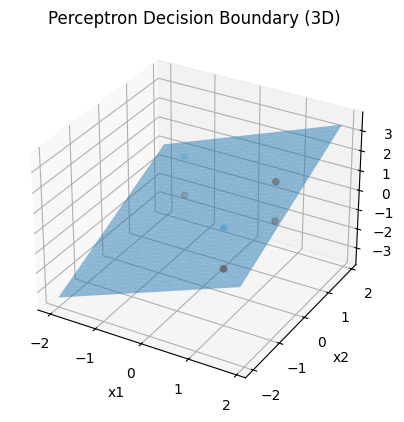

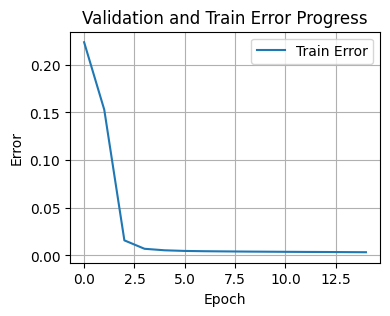

,Input,Predicted,True
0,"[1, -1, -1]",[0.9650276168162821],1
1,"[1, -1, 1]",[-0.928024188796152],-1
2,"[-1, 1, -1]",[0.9664184541677165],1
3,"[-1, 1, 1]",[-0.9251037526704916],-1
4,"[1, 1, -1]",[0.9999416417810207],1
5,"[1, 1, 1]",[0.9158571588214944],1


In [168]:
# Data and parameters:
inputs, true_outputs = example_gallblader_attack()
data_description = "Gallbladder Attack"

print_progress = True
activation = 'tanh'
learning_rate = 0.5
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 15

# Train the linear neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
# perceptron.set_weights(np.array([10000, 10000]), 10000) # set weights to large values
train_errors, val_errors =  perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress=print_progress)
# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
error = perceptron_error(true_outputs, real_outputs)
print(f"Perceptron error: {error}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
plot_decision_boundary_3D(perceptron, inputs, true_outputs)
plot_error_progress(train_errors, val_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


- finetune parameters of the algorithm:
    1. number of epochs
    2. learning rate
    3. adaptive learning rate or not?

In [169]:
# DataFrame to store the results for comparisons:
experiment_results_r = pd.DataFrame(columns=['MSE', 'MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

inputs, true_outputs = example_gallblader_attack()
data_description_orig = "Gallbladder Attack"

# Perceptron parameters:
variant = "iterative"
activation = 'tanh'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 100
learning_rate = 0.1
init_method = 'random'
print_progress = False

data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)

# learning rate:
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, activation, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# epochs:
learning_rate = 0.1
for epochs in [2, 5, 10, 20]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, activation, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# adaptive learning rate:
adaptive_learning_rate = True
data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)
epochs = 100
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, activation, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

print("\nExperiment Results:")
experiment_results_r


Experiment Results:


,MSE,MAE,Epochs,Time,Variant,Learning Rate,Max Epochs,Weights,Bias,Data Description
0,0.097140,0.268137,100.0,0.021666,iterative,0.01,100,"[[0.6444493686999834], [0.6435902970760207], [...",0.261034,Gallbladder Attack non-adaptive 0.0001
1,0.007054,0.072101,100.0,0.013733,iterative,0.10,100,"[[1.4045199911236164], [1.4042521469725304], [...",0.208214,Gallbladder Attack non-adaptive 0.0001
2,0.000209,0.011286,91.0,0.012826,iterative,1.00,100,"[[2.69959298003784], [2.4607934080354457], [-2...",0.143903,Gallbladder Attack non-adaptive 0.0001
3,0.328115,0.522841,2.0,0.000306,iterative,0.10,2,"[[0.28541106200312333], [0.2716660388822144], ...",0.203613,Gallbladder Attack non-adaptive 0.0001
4,0.156978,0.345514,5.0,0.000707,iterative,0.10,5,"[[0.5006806142074597], [0.5226154560675113], [...",0.239696,Gallbladder Attack non-adaptive 0.0001
5,0.080582,0.244660,10.0,0.001354,iterative,0.10,10,"[[0.7181240725560575], [0.7086572714059963], [...",0.245107,Gallbladder Attack non-adaptive 0.0001
6,0.039091,0.169663,20.0,0.002660,iterative,0.10,20,"[[0.9255661938890605], [0.9266936546420392], [...",0.225251,Gallbladder Attack non-adaptive 0.0001
7,0.360296,0.560574,100.0,0.014022,iterative,0.01,100,"[[0.2437673468170562], [0.27169944065511487], ...",0.142081,Gallbladder Attack adaptive 0.0001
8,0.045095,0.181506,100.0,0.015308,iterative,0.10,100,"[[0.8895448653990579], [0.8894102877038741], [...",0.234079,Gallbladder Attack adaptive 0.0001
9,0.001178,0.023833,90.3,0.012059,iterative,1.00,100,"[[1.7530997142246254], [1.7718833381258405], [...",0.346871,Gallbladder Attack adaptive 0.0001


## Example 2 - Linear regression with two input dimensions
- we will observe whether the neuron with tanh activation is able to learn linear regression task
- we set the parameters A, B, C, std_noise close to zero (|A| + |B| + |C| + std_noise < 1), so that the values are mostly in the interval [-1, 1], which is the range of the hyperbolic tangent function

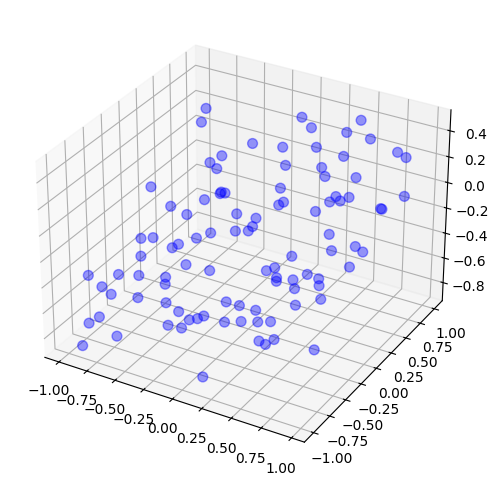

In [170]:
def generate_regression_data_2D(A=0.2, B=0.4, C=-0.2, std_noise=0.15, number_of_samples=100, input_range= 1):
    # y = A x1 + B x2 + C + noise

    # Generate x1 and x2 from a uniform distribution (more variation than linspace)
    x1 = np.random.uniform(-input_range, input_range, number_of_samples).reshape(-1, 1)
    x2 = np.random.uniform(-input_range, input_range, number_of_samples).reshape(-1, 1)
    x2 = x2[np.random.permutation(number_of_samples)]  # Randomly shuffle x2
    inputs = np.hstack([x1, x2])

    # Define true function with noise
    noise = np.random.normal(0, std_noise, size=x1.shape)  # Gaussian noise
    true_outputs = A*x1 + B*x2 + C + noise
    return inputs, true_outputs.flatten()

# plot the data in 3d:
inputs, true_outputs = generate_regression_data_2D()
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(inputs[:, 0], inputs[:, 1], true_outputs.flatten(), label="Data points, true outputs", color='blue', alpha=0.4, s=50)


- at first we train the standard linear neuron:

Gradient Descent iterative:
Epoch: 0, Training MSE: 0.2796, Validation MSE: 0.2505 Val steps: 0 Weights: [[0.18020758 0.32035217]] Bias: -0.045911327499774154 Learning rate: 0.0005
Epoch: 1, Training MSE: 0.0540, Validation MSE: 0.0461 Val steps: 0 Weights: [[0.19804921 0.38284083]] Bias: -0.0532383533425496 Learning rate: 0.0005
Epoch: 2, Training MSE: 0.0435, Validation MSE: 0.0407 Val steps: 0 Weights: [[0.20161999 0.39890934]] Bias: -0.060084636939741275 Learning rate: 0.0005
Epoch: 3, Training MSE: 0.0422, Validation MSE: 0.0404 Val steps: 0 Weights: [[0.201368   0.40241427]] Bias: -0.06677664658480734 Learning rate: 0.0005
Epoch: 4, Training MSE: 0.0400, Validation MSE: 0.0377 Val steps: 0 Weights: [[0.20085    0.39966262]] Bias: -0.07320889794889653 Learning rate: 0.0005
Epoch: 5, Training MSE: 0.0384, Validation MSE: 0.0362 Val steps: 0 Weights: [[0.19964009 0.39957302]] Bias: -0.07929253838562549 Learning rate: 0.0005
Epoch: 6, Training MSE: 0.0372, Validation MSE: 0.0355 Val 

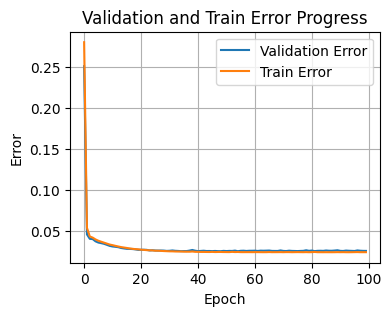

Train Perceptron error: 100, Test PE: 100
Train MAE error: 0.12109194762846152, Test MAE: 0.12688371379270447
Train MSE error: 0.024473742586367857, Test MSE: 0.02569664214383307


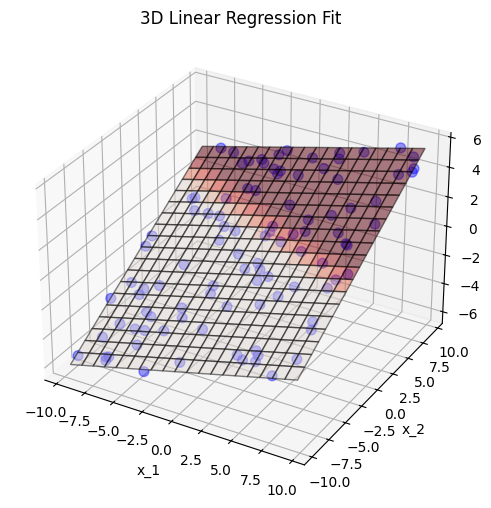

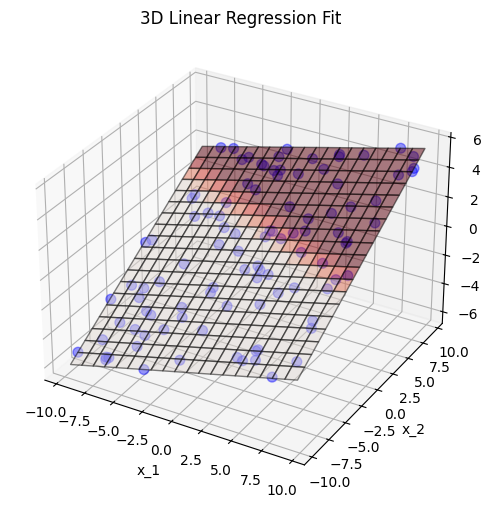

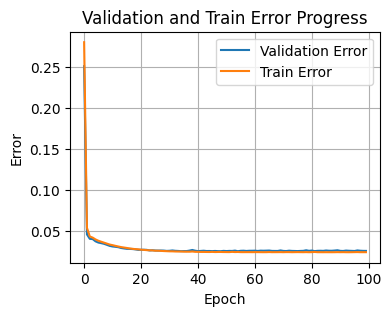

,Input,Predicted,True
0,"[-4.764162137058483, -7.00744810826423]",[-3.944578980813307],-3.605894
1,"[0.24749606032101568, 7.041758002727306]",[2.664463282961828],2.575978
2,"[-5.889180584187761, -6.573448747514545]",[-3.995755086213898],-3.963911
3,"[-2.001349503772918, 7.3030162782689985]",[2.320106488754063],2.424379
4,"[8.226942196121485, -5.099987925849343]",[-0.5911812835906936],-0.647245
...,...,...,...
95,"[-7.861907989292325, 9.29073183539186]",[1.944472224167281],1.915276
96,"[2.674898424655277, 1.9535363078713743]",[1.117269518941483],1.049360
97,"[-1.4383675339018875, 6.86458330405414]",[2.2573811994491804],2.365805
98,"[-4.870018993557313, -7.9273815723498835]",[-4.332983529298911],-4.231553


In [171]:
# Define parameters
inputs, true_outputs = generate_regression_data_2D(A=0.2, B=0.4, C=-0.2, std_noise=0.15, number_of_samples=100, input_range=10)
test_inputs, test_true_outputs = generate_regression_data_2D(A=0.2, B=0.4, C=-0.2, std_noise=0.15, number_of_samples=100, input_range=10)
validation_data = generate_regression_data_2D(A=0.2, B=0.4, C=-0.2, std_noise=0.15, number_of_samples=100, input_range=10)

# Train the linear neuron:
print_progress = True
learning_rate = 0.0005
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 100
variant = "iterative"
max_validation_steps = None # no early stopping
activation = 'linear'

# Train the linear neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)

# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_regression_3D(perceptron, inputs, true_outputs)
plot_regression_3D(perceptron, inputs, real_outputs)
plot_error_progress(training_errors, validation_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df

- than we train the same task using tanh activation function
- observe, that the regression task is very difficult for a perceptron with tanh activation function and that it is very sensitive to the choice of initial learning rate:

Gradient Descent iterative:
Epoch: 0, Training MSE: 4.1642, Validation MSE: 3.6727 Val steps: 0 Weights: [[0.09664728 0.21726641]] Bias: 0.06816305587783503 Learning rate: 0.0005
Epoch: 1, Training MSE: 4.0531, Validation MSE: 3.5592 Val steps: 0 Weights: [[0.12236942 0.26270097]] Bias: 0.07171173243914954 Learning rate: 0.0005
Epoch: 2, Training MSE: 4.0106, Validation MSE: 3.5141 Val steps: 0 Weights: [[0.13777455 0.29151138]] Bias: 0.07469841643880044 Learning rate: 0.0005
Epoch: 3, Training MSE: 3.9879, Validation MSE: 3.4894 Val steps: 0 Weights: [[0.14829508 0.3130573 ]] Bias: 0.07740400630991032 Learning rate: 0.0005
Epoch: 4, Training MSE: 3.9737, Validation MSE: 3.4739 Val steps: 0 Weights: [[0.15624979 0.33025876]] Bias: 0.07993747356900009 Learning rate: 0.0005
Epoch: 5, Training MSE: 3.9638, Validation MSE: 3.4628 Val steps: 0 Weights: [[0.16377538 0.34417428]] Bias: 0.08243988620822275 Learning rate: 0.0005
Epoch: 6, Training MSE: 3.9566, Validation MSE: 3.4547 Val steps: 

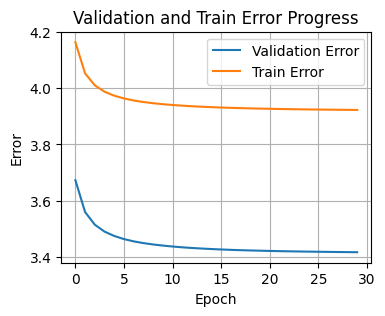

Train Perceptron error: 100, Test PE: 100
Train MAE error: 1.5648254399019705, Test MAE: 1.4169867521772992
Train MSE error: 3.922909307138485, Test MSE: 3.114825402284676
True outputs


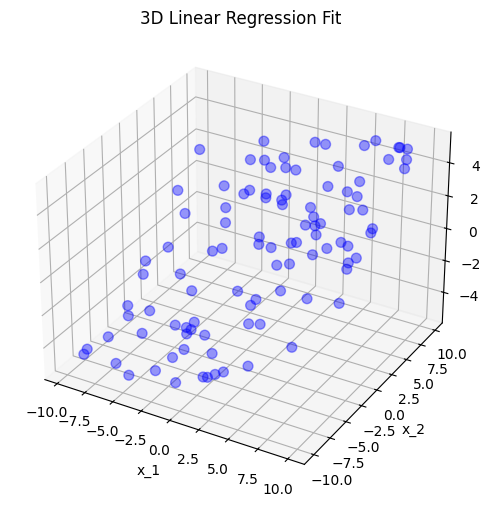

Real outputs


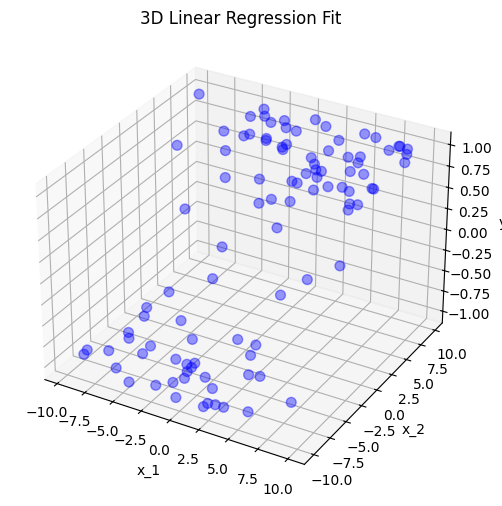

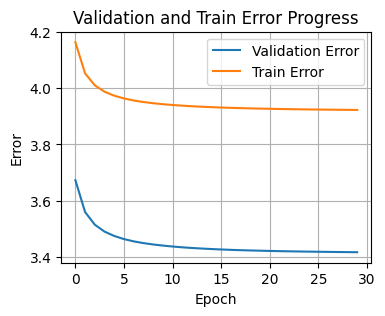

,Input,Predicted,True
0,"[-5.776861100844879, -4.741736983258978]",[-0.9979602145691954],-2.982232
1,"[9.578134881792899, 2.092192645611439]",[0.9972333695445679],2.734732
2,"[9.437096731158078, 2.1099768717291667]",[0.9971015292623867],2.450477
3,"[6.9459430554358335, -3.1115833225266503]",[0.2040508947339095],-0.156990
4,"[5.37806985827279, 0.5954682698304872]",[0.9256536305426003],0.854010
...,...,...,...
95,"[8.112192055123373, 9.102147725689104]",[0.9999934507174257],5.003487
96,"[-4.494561108223499, -9.901761788289928]",[-0.9999739033169686],-4.780269
97,"[4.398294250784222, 2.75574406155509]",[0.9849157586711493],1.666874
98,"[-1.448963309918609, -6.470184042066944]",[-0.9972513142003933],-2.853424


In [184]:
# Define parameters
inputs, true_outputs = generate_regression_data_2D(A=0.2, B=0.4, C=-0.2, std_noise=0.15, number_of_samples=100, input_range=10)
test_inputs, test_true_outputs = generate_regression_data_2D(A=0.2, B=0.4, C=-0.2, std_noise=0.15, number_of_samples=100, input_range=10)
validation_data = generate_regression_data_2D(A=0.2, B=0.4, C=-0.2, std_noise=0.15, number_of_samples=100, input_range=10)

# Train the linear neuron:
print_progress = True
learning_rate = 0.0005
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 30
variant = "iterative"
max_validation_steps = None # no early stopping
activation = 'tanh'

# Train the linear neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)

# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
print("True outputs")
plot_regression_3D(perceptron, inputs, true_outputs)
print("Real outputs")
plot_regression_3D(perceptron, inputs, real_outputs)
plot_error_progress(training_errors, validation_errors)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df

## Example 3:  Randomly Generated Clustered Data


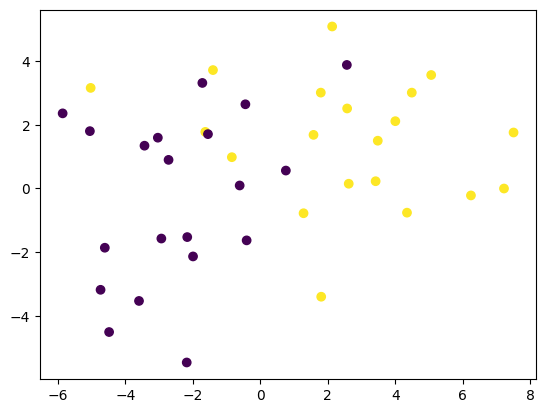

In [173]:
def example_random_clusters(N = 40, spread = 2.5):
    """ Generate two separable clusters """
    cluster_1 = np.random.randn(N//2, 2) * spread + np.array([2, 2])
    cluster_2 = np.random.randn(N//2, 2) * spread + np.array([-2, -2])
    inputs = np.vstack((cluster_1, cluster_2))
    true_outputs = np.hstack((np.ones(N//2), -np.ones(N//2)))  # Labels for clusters
    return inputs, true_outputs.flatten()

# vizualize the clusters
inputs, true_outputs = example_random_clusters()
plt.scatter(inputs[:, 0], inputs[:, 1], c=true_outputs)

- Set the parameters, run the experiment and observe the results:
- Compare the results with the Rosenblatt training algorithm (perceptron_examples.ipynb)
- Experiment with the learning rate and other training parameters (maximum number of epochs, adaptive learning rate) and observe, how it affects the training process and the outputs
- Experiment with biased weights and observe how they affect training

Gradient Descent iterative:
Epoch: 0, Training MSE: 0.8521, Validation MSE: 0.8782 Val steps: 0 Weights: [[ 0.05992087 -0.01554892]] Bias: -0.09077893548395281 Learning rate: 0.0010
Epoch: 1, Training MSE: 0.6505, Validation MSE: 0.6497 Val steps: 0 Weights: [[0.10410199 0.02878598]] Bias: -0.08596854692187816 Learning rate: 0.0007
Epoch: 2, Training MSE: 0.5851, Validation MSE: 0.5787 Val steps: 0 Weights: [[0.12634278 0.04913486]] Bias: -0.08226667401397075 Learning rate: 0.0006
Epoch: 3, Training MSE: 0.5509, Validation MSE: 0.5437 Val steps: 0 Weights: [[0.14154324 0.06167334]] Bias: -0.07940684133841958 Learning rate: 0.0005
Epoch: 4, Training MSE: 0.5290, Validation MSE: 0.5226 Val steps: 0 Weights: [[0.15290615 0.07076243]] Bias: -0.07690175644289558 Learning rate: 0.0004
Epoch: 5, Training MSE: 0.5133, Validation MSE: 0.5082 Val steps: 0 Weights: [[0.16224608 0.077735  ]] Bias: -0.07472749355502066 Learning rate: 0.0004
Epoch: 6, Training MSE: 0.5013, Validation MSE: 0.4977 Val

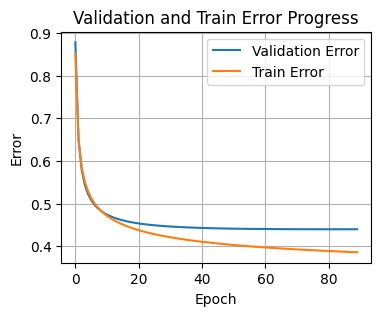

Train Perceptron error: 5, Validation PE: 7, Test PE: 4
Train MAE error: 0.47362024491406973, Validation MAE: 0.4659081838324436, Test MAE: 0.41897914032183126
Train MSE error: 0.3861262716947811, Validation MSE: 0.4399721278470616, Test MSE: 0.36155462641519664


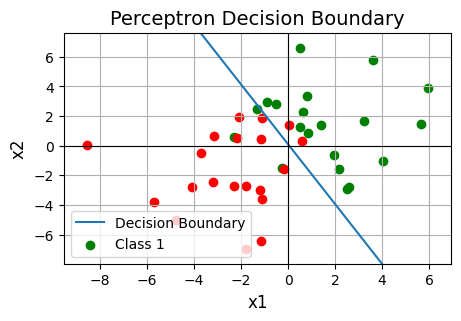

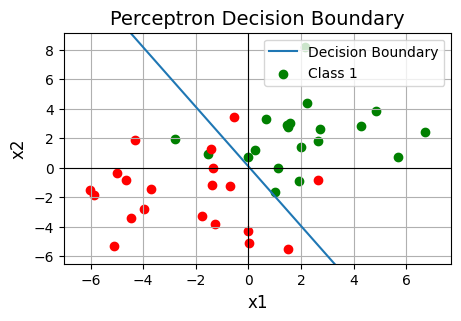

,Input,Predicted,True
0,"[3.241785382528082, 1.6543392470720384]",[0.8490077591326228],1.0
1,"[3.6192213452517312, 5.8075746410200635]",[0.9649156992213218],1.0
2,"[1.41461656319166, 1.4146576076270487]",[0.5683389140232852],1.0
3,"[5.948032038768479, 3.918586822882272]",[0.9851482165351346],1.0
4,"[0.8263140351626197, 3.3564001089649116]",[0.6420681358352938],1.0
5,"[0.8414557679688444, 0.8356756160743579]",[0.3597346466496962],1.0
6,"[2.6049056789150855, -2.783200611644495]",[0.3517877649691274],1.0
7,"[-2.3122945812825817, 0.5942811768975682]",[-0.5685478085749144],1.0
8,"[-0.5320778008360594, 2.785618331488185]",[0.24427294784199638],1.0
9,"[-0.2700601888030274, -1.5307592533382288]",[-0.3242705960178863],1.0


In [174]:
# Data and parameters:
np.random.seed(42)
inputs, true_outputs = example_random_clusters()
test_inputs, test_true_outputs = example_random_clusters()
validation_data = example_random_clusters()
data_description = "Clusters"

activation = 'tanh'
print_progress = True
learning_rate = 0.001
init_method = 'random'
adaptive_learning_rate = True #False
min_error = 0.0001
epochs = 100
variant = "iterative" #"batch" #"iterative"
max_validation_steps = 5 #  early stopping

# Train the neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
# perceptron.set_weights(np.array([10000, 10000]), 10000) # set weights to large values
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)


# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
val_outputs = perceptron.forward(validation_data[0])
test_outputs = perceptron.forward(test_inputs)
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Validation PE: {perceptron_error(validation_data[1], val_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Validation MAE: {MAE_error(validation_data[1], val_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Validation MSE: {MSE_error(validation_data[1], val_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)
plot_decision_boundary_2D(perceptron, test_inputs, test_true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


### 3.a Randomly Generated Clustered Data and Biased Weights
- observe how biased weights the impact the training process.Do you observe the perceptron saturate?
- experiment with the initial weigt vector

Gradient Descent iterative:
Epoch: 0, Training MSE: 1.8000, Validation MSE: 1.9000 Val steps: 1 Weights: [[ 1000. -1000.]] Bias: 999.9960000000001 Learning rate: 0.0010
Epoch: 1, Training MSE: 1.8000, Validation MSE: 1.9000 Val steps: 2 Weights: [[ 1000. -1000.]] Bias: 999.9920000000002 Learning rate: 0.0007
Epoch: 2, Training MSE: 1.8000, Validation MSE: 1.9000 Val steps: 3 Weights: [[ 1000. -1000.]] Bias: 999.9891715728754 Learning rate: 0.0006
Epoch: 3, Training MSE: 1.8000, Validation MSE: 1.9000 Val steps: 4 Weights: [[ 1000. -1000.]] Bias: 999.9868621717987 Learning rate: 0.0005
Epoch: 4, Training MSE: 1.8000, Validation MSE: 1.9000 Val steps: 5 Weights: [[ 1000. -1000.]] Bias: 999.9848621717988 Learning rate: 0.0004
Epoch: 5, Training MSE: 1.8000, Validation MSE: 1.9000 Val steps: 6 Weights: [[ 1000. -1000.]] Bias: 999.9830733174167 Learning rate: 0.0004
Epoch: 6, Training MSE: 1.8000, Validation MSE: 1.9000 Val steps: 7 Weights: [[ 1000. -1000.]] Bias: 999.9814403242549 Learnin

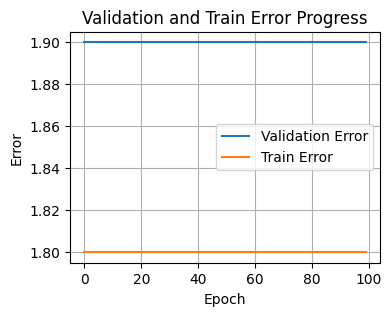

Train Perceptron error: 18, Validation PE: 19, Test PE: 17
Train MAE error: 0.9, Validation MAE: 0.95, Test MAE: 0.85
Train MSE error: 1.8, Validation MSE: 1.9, Test MSE: 1.7


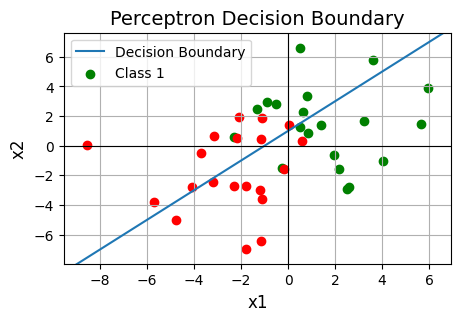

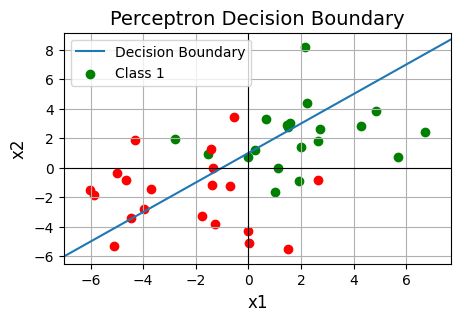

,Input,Predicted,True
0,"[3.241785382528082, 1.6543392470720384]",[1.0],1.0
1,"[3.6192213452517312, 5.8075746410200635]",[-1.0],1.0
2,"[1.41461656319166, 1.4146576076270487]",[1.0],1.0
3,"[5.948032038768479, 3.918586822882272]",[1.0],1.0
4,"[0.8263140351626197, 3.3564001089649116]",[-1.0],1.0
5,"[0.8414557679688444, 0.8356756160743579]",[1.0],1.0
6,"[2.6049056789150855, -2.783200611644495]",[1.0],1.0
7,"[-2.3122945812825817, 0.5942811768975682]",[-1.0],1.0
8,"[-0.5320778008360594, 2.785618331488185]",[-1.0],1.0
9,"[-0.2700601888030274, -1.5307592533382288]",[1.0],1.0


In [175]:
# Data and parameters:
np.random.seed(42)
inputs, true_outputs = example_random_clusters()
test_inputs, test_true_outputs = example_random_clusters()
validation_data = example_random_clusters()
data_description = "Clusters"

activation = 'tanh'
print_progress = True
learning_rate = 0.001
init_method = 'random'
adaptive_learning_rate = True #False
min_error = 0.0001
epochs = 100
variant = "iterative" #"batch" #"iterative"
max_validation_steps = None #  early stopping

# Train the neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
perceptron.set_weights(np.array([1000, -1000]), 1000) # set weights to large values
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)


# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
val_outputs = perceptron.forward(validation_data[0])
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Validation PE: {perceptron_error(validation_data[1], val_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Validation MAE: {MAE_error(validation_data[1], val_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Validation MSE: {MSE_error(validation_data[1], val_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)
plot_decision_boundary_2D(perceptron, test_inputs, test_true_outputs)


# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


### 3.b Randomly Generated Clustered Data and Overfitting
- observe overfitting for small datsets and try to apply early stopping:
- try both the iterative and batch variant:

Gradient Descent iterative:
Epoch: 0, Training MSE: 0.3481, Validation MSE: 0.3449 Val steps: 0 Weights: [[0.20595894 0.21689666]] Bias: -0.06739246270879914 Learning rate: 0.0100
Epoch: 1, Training MSE: 0.3274, Validation MSE: 0.3238 Val steps: 0 Weights: [[0.27184993 0.23607765]] Bias: -0.09388683698277268 Learning rate: 0.0071
Epoch: 2, Training MSE: 0.3217, Validation MSE: 0.3203 Val steps: 0 Weights: [[0.29743322 0.2435676 ]] Bias: -0.11248938641786649 Learning rate: 0.0058
Epoch: 3, Training MSE: 0.3189, Validation MSE: 0.3193 Val steps: 0 Weights: [[0.31084968 0.24858804]] Bias: -0.12695540945843226 Learning rate: 0.0050
Epoch: 4, Training MSE: 0.3170, Validation MSE: 0.3186 Val steps: 0 Weights: [[0.32144104 0.25244765]] Bias: -0.13743808870163493 Learning rate: 0.0045
Epoch: 5, Training MSE: 0.3156, Validation MSE: 0.3184 Val steps: 0 Weights: [[0.33040438 0.25521655]] Bias: -0.14687068531904102 Learning rate: 0.0041
Epoch: 6, Training MSE: 0.3144, Validation MSE: 0.3181 Val s

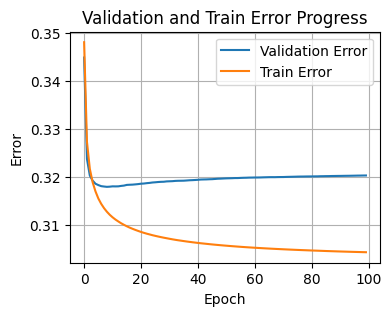

Train Perceptron error: 4, Validation PE: 5, Test PE: 13
Train MAE error: 0.3083362395204001, Validation MAE: 0.3298174272605134, Test MAE: 0.5280757282081335
Train MSE error: 0.30435780375277044, Validation MSE: 0.320353611082813, Test MSE: 0.6723140645748781


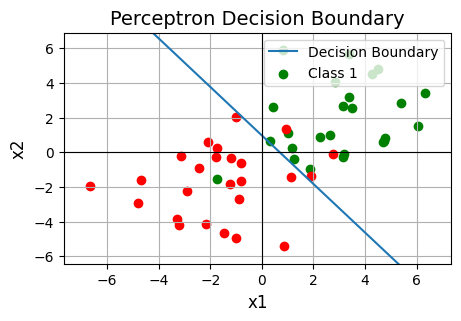

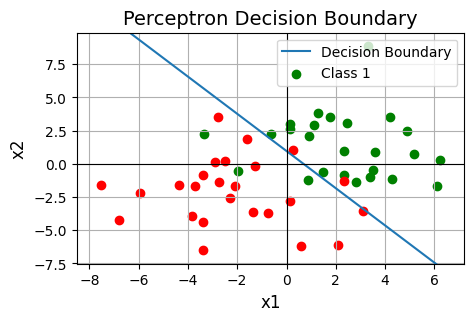

In [176]:
# Data and parameters:
np.random.seed(114570)
inputs, true_outputs = example_random_clusters(N=50, spread=2.5)
test_inputs, test_true_outputs = example_random_clusters(N=50, spread=2.5)
validation_data = example_random_clusters(N=50, spread=2.5)
data_description = "Clusters"

activation = 'tanh'
print_progress = True
learning_rate = 0.01
init_method = 'random'
adaptive_learning_rate = True #False
min_error = 0.0001
epochs = 100
variant = "iterative" #"batch" #"batch" #"iterative"
max_validation_steps = None #5 # None #None # 5 # None # 5 #  early stopping

# Train the neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)


# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
val_outputs = perceptron.forward(validation_data[0])
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Validation PE: {perceptron_error(validation_data[1], val_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Validation MAE: {MAE_error(validation_data[1], val_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Validation MSE: {MSE_error(validation_data[1], val_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)
plot_decision_boundary_2D(perceptron, validation_data[0], validation_data[1])

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
#df

- finetune parameters of the algorithm:
    1. number of epochs
    2. learning rate
    3. adaptive learning rate or not?

In [177]:
# DataFrame to store the results for comparisons:
experiment_results_r = pd.DataFrame(columns=['MSE', 'MAE', 'Test MSE', 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

np.random.seed(42) # For reproducibility
inputs, true_outputs = example_random_clusters()
test_inputs, test_true_outputs = example_random_clusters()
validation_data = example_random_clusters()
data_description = "Clusters"

activation = 'tanh'
print_progress = False
learning_rate = 0.001
init_method = 'random'
adaptive_learning_rate = True #False
min_error = 0.0001
epochs = 100
variant = "iterative" #"batch" #"iterative"
max_validation_steps = None #5 #  early stopping



data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)

# learning rate:
for learning_rate in [0.0001, 0.001 , 0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, activation, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# epochs:
learning_rate = 0.1
for epochs in [2, 5, 10, 20]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, activation, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)

# adaptive learning rate:
adaptive_learning_rate = True
data_description = data_description_orig + " " + ("adaptive " if adaptive_learning_rate else "non-adaptive ") + str(min_error)
epochs = 100
for learning_rate in [0.01, 0.1 , 1]:
    run_example_multiple_times(experiment_results_r, (inputs, true_outputs), None, None, activation, epochs, init_method , learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=None)


print("\nExperiment Results:")
experiment_results_r


Experiment Results:


,MSE,MAE,Test MSE,Test MAE,Epochs,Time,Variant,Learning Rate,Max Epochs,Weights,Bias,Data Description
0,0.604414,0.732918,0.604414,0.732918,100.0,0.115757,iterative,0.0001,100,"[[0.08044191072123376], [0.09429881661023408]]",0.021913,Gallbladder Attack adaptive 0.0001
1,0.376894,0.465394,0.376894,0.465394,100.0,0.113094,iterative,0.0010,100,"[[0.3150667527783813], [0.15528255695452423]]",0.093826,Gallbladder Attack adaptive 0.0001
2,0.345694,0.363075,0.345694,0.363075,100.0,0.094937,iterative,0.0100,100,"[[0.5295645847382462], [0.22724763609804374]]",0.190927,Gallbladder Attack adaptive 0.0001
3,0.346599,0.352678,0.346599,0.352678,100.0,0.065927,iterative,0.1000,100,"[[0.5675054071204626], [0.23631770166660704]]",0.218812,Gallbladder Attack adaptive 0.0001
4,0.411798,0.222228,0.411798,0.222228,100.0,0.063534,iterative,1.0000,100,"[[6.411909721485936], [4.391370176366897]]",-1.585643,Gallbladder Attack adaptive 0.0001
5,0.391206,0.326724,0.391206,0.326724,2.0,0.001233,iterative,0.1000,2,"[[0.7578236959678806], [0.29710092423648393]]",0.239611,Gallbladder Attack adaptive 0.0001
6,0.359133,0.316292,0.359133,0.316292,5.0,0.003037,iterative,0.1000,5,"[[0.7321770088179876], [0.2651013415348344]]",0.191126,Gallbladder Attack adaptive 0.0001
7,0.352446,0.331204,0.352446,0.331204,10.0,0.006075,iterative,0.1000,10,"[[0.7102272123034281], [0.3545974326470023]]",0.303721,Gallbladder Attack adaptive 0.0001
8,0.349027,0.342990,0.349027,0.342990,20.0,0.012629,iterative,0.1000,20,"[[0.6017146633207967], [0.2239197771302134]]",0.211740,Gallbladder Attack adaptive 0.0001
9,0.345730,0.363098,0.345730,0.363098,100.0,0.061046,iterative,0.0100,100,"[[0.5295095888139785], [0.2270592688014]]",0.193374,Gallbladder Attack adaptive 0.0001


## Example 4:  Randomly Generated Clustered Data And Normalization


- the input data are shifted:

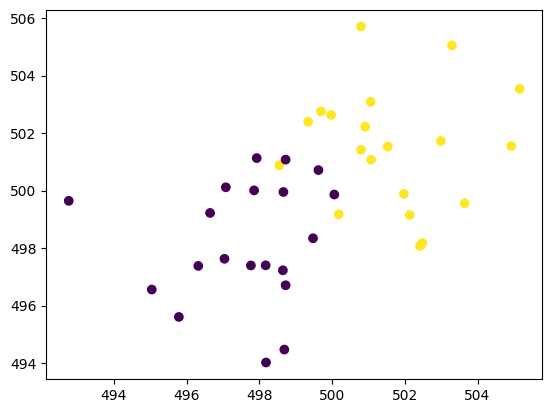

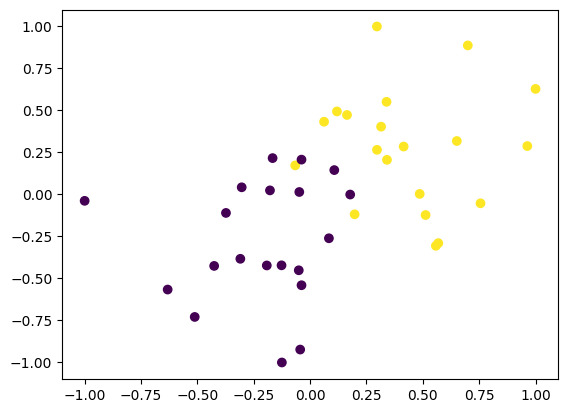

In [178]:
def example_shifted_clusters():
    """ Generate two separable clusters """
    N=40
    spread=2.0
    cluster_1 = np.random.randn(N//2, 2) * spread + np.array([2, 2]) + 500
    cluster_2 = np.random.randn(N//2, 2) * spread + np.array([-2, -2]) + 500
    inputs = np.vstack((cluster_1, cluster_2))
    true_outputs = np.hstack((np.ones(N//2), -np.ones(N//2)))  # Labels for clusters
    return inputs, true_outputs

def normalize_data(data):
    """Normalizes data to the range [-1, 1]."""
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)

    # Avoid division by zero if min and max are the same
    max_vals = np.where(max_vals == min_vals, max_vals + 1e-6, max_vals)

    normalized_data = 2 * (data - min_vals) / (max_vals - min_vals) - 1
    return normalized_data

def example_normalized_clusters():
    inputs, true_outputs = example_shifted_clusters()
    return normalize_data(inputs), true_outputs

# vizualize
np.random.seed(42)
inputs, true_outputs = example_shifted_clusters()
plt.scatter(inputs[:, 0], inputs[:, 1], c=true_outputs)

plt.figure()
np.random.seed(42)
inputs, true_outputs = example_normalized_clusters()
plt.scatter(inputs[:, 0], inputs[:, 1], c=true_outputs)

- Set the parameters, run the experiment and observe the results:
- Observe, that it is very difficult for the perceptron to learn the task, if the input data is not normalized
- Normalize the data and run the experiment again

Gradient Descent iterative:
Epoch: 0, Training MSE: 2.0000, Validation MSE: 2.0000 Val steps: 0 Weights: [[-0.05883797  0.07537199]] Bias: -0.0966345668761365 Learning rate: 0.0005
Epoch: 1, Training MSE: 2.0000, Validation MSE: 2.0000 Val steps: 0 Weights: [[-0.05884188  0.0753681 ]] Bias: -0.11663456332598059 Learning rate: 0.0004
Epoch: 2, Training MSE: 2.0000, Validation MSE: 2.0000 Val steps: 0 Weights: [[-0.05884475  0.07536523]] Bias: -0.13077669634314742 Learning rate: 0.0003
Epoch: 3, Training MSE: 2.0000, Validation MSE: 2.0000 Val steps: 0 Weights: [[-0.05884718  0.07536281]] Bias: -0.14232369952790871 Learning rate: 0.0003
Epoch: 4, Training MSE: 2.0000, Validation MSE: 2.0000 Val steps: 0 Weights: [[-0.05884933  0.07536066]] Bias: -0.15232369757527134 Learning rate: 0.0002
Epoch: 5, Training MSE: 2.0000, Validation MSE: 2.0000 Val steps: 0 Weights: [[-0.0588513  0.0753587]] Bias: -0.16126796769590607 Learning rate: 0.0002
Epoch: 6, Training MSE: 2.0000, Validation MSE: 2.0

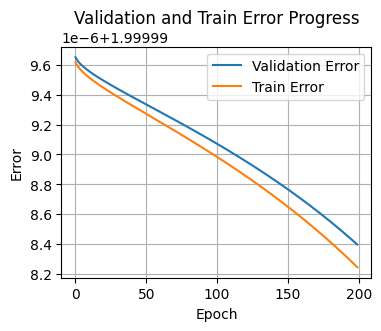

Train Perceptron error: 20, Test PE: 20
Train MAE error: 0.9999999182373337, Test MAE: 0.9999999528351615
Train MSE error: 1.999998244123247, Test MSE: 1.99999837742805


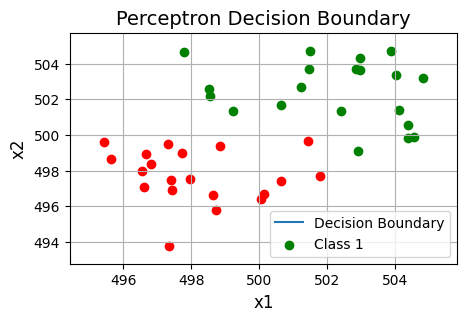

,Input,Predicted,True
0,"[498.5072717037158, 502.55835546726917]",[0.9999995797475152],1.0
1,"[504.0145407926594, 503.35730013198133]",[0.9999992856584627],1.0
2,"[504.3854188174532, 499.82065238077416]",[0.9999987300966698],1.0
3,"[500.64789099468214, 501.679817566812]",[0.9999993824472185],1.0
4,"[504.0993940230951, 501.3805209317769]",[0.9999990288556684],1.0
5,"[499.2383771598388, 501.3649525294433]",[0.999999451833864],1.0
6,"[502.40607833134186, 501.3327193478532]",[0.9999991991879722],1.0
7,"[497.7924515736284, 504.68013048988416]",[0.999999719231164],1.0
8,"[502.9163893252042, 499.11467338600744]",[0.9999988129104597],1.0
9,"[504.56302132735885, 499.89578571177276]",[0.9999987177333404],1.0


In [179]:
def example_random_clusters():
  return example_shifted_clusters()
  # return example_normalized_clusters()

# Data and parameters:
np.random.seed(642)
inputs, true_outputs = example_random_clusters()
test_inputs, test_true_outputs = example_random_clusters()
validation_data = example_random_clusters()
data_description = "Clusters"

activation = 'tanh'
print_progress = True
learning_rate = 0.0005
init_method = 'random'
adaptive_learning_rate = True #False
min_error = 0.0001
epochs = 200
variant = "iterative" #"batch" #"iterative"
max_validation_steps = 5 #  early stopping

# Train the neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)


# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


- normalize the data and run the experiment again:

Gradient Descent iterative:
Epoch: 0, Training MSE: 0.2568, Validation MSE: 0.4286 Val steps: 0 Weights: [[0.65662707 0.9303197 ]] Bias: -0.12984552967000096 Learning rate: 0.1000
Epoch: 1, Training MSE: 0.1815, Validation MSE: 0.3804 Val steps: 0 Weights: [[0.86773653 1.27346747]] Bias: -0.1542570797397904 Learning rate: 0.0707
Epoch: 2, Training MSE: 0.1586, Validation MSE: 0.3753 Val steps: 0 Weights: [[0.92196469 1.44905503]] Bias: -0.2124073770585808 Learning rate: 0.0577
Epoch: 3, Training MSE: 0.1450, Validation MSE: 0.3698 Val steps: 0 Weights: [[0.95731165 1.57143896]] Bias: -0.20203452346311182 Learning rate: 0.0500
Epoch: 4, Training MSE: 0.1363, Validation MSE: 0.3675 Val steps: 0 Weights: [[0.98583237 1.66232518]] Bias: -0.20965625482448946 Learning rate: 0.0447
Epoch: 5, Training MSE: 0.1299, Validation MSE: 0.3679 Val steps: 1 Weights: [[1.00238908 1.73692368]] Bias: -0.23177344434500752 Learning rate: 0.0408
Epoch: 6, Training MSE: 0.1251, Validation MSE: 0.3680 Val ste

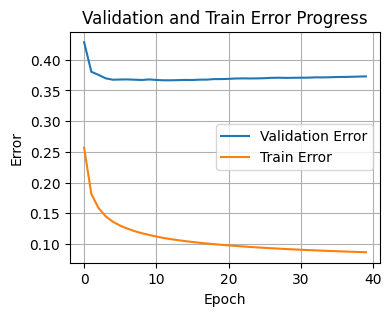

Train Perceptron error: 1, Test PE: 6
Train MAE error: 0.1770311857723179, Test MAE: 0.37490527244386873
Train MSE error: 0.08675288281647767, Test MSE: 0.4610599665791589


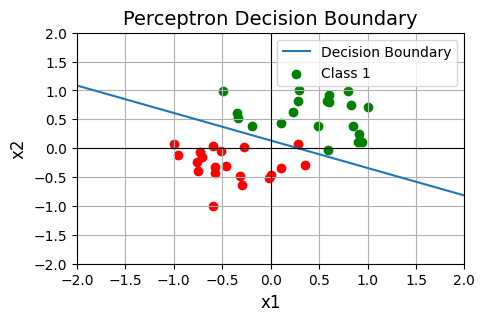

,Input,Predicted,True
0,"[-0.343649568119454, 0.6019865918489369]",[0.644858260767074],1.0
1,"[0.8270957930544727, 0.7478150561703909]",[0.9875991171126635],1.0
2,"[0.9059377236150226, 0.10228360301240436]",[0.7644154865727887],1.0
3,"[0.11140720583945352, 0.44163026364438207]",[0.7203734954665629],1.0
4,"[0.8451340483691963, 0.3870007372309723]",[0.9290076362491319],1.0
5,"[-0.1882298296862308, 0.3841590933668566]",[0.38348391884420874],1.0
6,"[0.48516589371645136, 0.3782756879458109]",[0.8328091946707098],1.0
7,"[-0.49560734208289836, 0.9892664709817871]",[0.9153900130049183],1.0
8,"[0.5936487405088506, -0.026576175639631994]",[0.2981060634290337],1.0
9,"[0.943692790826518, 0.11599741670040009]",[0.7956335606310091],1.0


In [180]:
def example_random_clusters():
  #return example_shifted_clusters() # comment this row to normalize the data
  return example_normalized_clusters()

# Data and parameters:
np.random.seed(642)
inputs, true_outputs = example_random_clusters()
test_inputs, test_true_outputs = example_random_clusters()
validation_data = example_random_clusters()
data_description = "Clusters"

activation = 'tanh'
print_progress = True
learning_rate = 0.1
init_method = 'random'
adaptive_learning_rate = True #False
min_error = 0.0001
epochs = 200
variant = "iterative" #"batch" #"iterative"
max_validation_steps = 5 #  early stopping

# Train the neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress=print_progress)


# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
test_outputs = perceptron.forward(test_inputs)
print(f"Train Perceptron error: {perceptron_error(true_outputs, real_outputs)}, Test PE: {perceptron_error(test_true_outputs, test_outputs)}")
print(f"Train MAE error: {MAE_error(true_outputs, real_outputs)}, Test MAE: {MAE_error(test_true_outputs, test_outputs)}")
print(f"Train MSE error: {MSE_error(true_outputs, real_outputs)}, Test MSE: {MSE_error(test_true_outputs, test_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


## Example 5  - Outliers

In [181]:
def example_outliers():
    # data with outliers
    inputs = np.array([
        [-0.5, -0.5],
        [ 0.3, -0.5],
        [ -40,   50], # outlier
        [ -0.8, 1],
        [ -0.1, 1.0]
    ])

    true_outputs = np.array([1, 1, -1, -1, 1])
    return inputs, true_outputs

def normalize_data(data):
    """Normalizes data to the range [-1, 1]."""
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)

    # Avoid division by zero if min and max are the same
    max_vals = np.where(max_vals == min_vals, max_vals + 1e-6, max_vals)

    normalized_data = 2 * (data - min_vals) / (max_vals - min_vals) - 1
    return normalized_data

def example_normalized_outliers():
    inputs, true_outputs = example_outliers()
    return normalize_data(inputs), true_outputs

def normalize_data_std(data):
    """Normalizes data using standard deviation."""
    mean_vals = np.mean(data, axis=0)
    std_vals = np.std(data, axis=0)

    # Avoid division by zero if standard deviation is zero
    std_vals = np.where(std_vals == 0, 1e-6, std_vals)  # Add a small value to avoid division by zero

    normalized_data = (data - mean_vals) / std_vals
    return normalized_data

def example_std_normalized_outliers():
    inputs, true_outputs = example_outliers()
    return normalize_data_std(inputs), true_outputs

inputs, true_outputs = example_outliers()
norm_inputs = normalize_data(inputs)
std_norm_inputs = normalize_data_std(inputs)
print(inputs)
print(norm_inputs)
print(std_norm_inputs)

[[ -0.5  -0.5]
 [  0.3  -0.5]
 [-40.   50. ]
 [ -0.8   1. ]
 [ -0.1   1. ]]
[[ 0.96029777 -1.        ]
 [ 1.         -1.        ]
 [-1.          1.        ]
 [ 0.94540943 -0.94059406]
 [ 0.98014888 -0.94059406]]
[[ 0.48570792 -0.53738321]
 [ 0.53604034 -0.53738321]
 [-1.99945565  1.99886463]
 [ 0.46683326 -0.46204911]
 [ 0.51087413 -0.46204911]]


- Set the parameters, run the experiment and observe the results:
- Observe, that the percepron is able to learn the task

Gradient Descent iterative:
Epoch: 0, MSE: 0.1922 Weights: [[ 0.93845042 -1.11668625]] Bias: 1.446899587907085 Learning rate: 0.8000
Epoch: 1, MSE: 0.5720 Weights: [[ 1.50026526 -1.39125543]] Bias: 0.7735075060666863 Learning rate: 0.5657
Epoch: 2, MSE: 0.1858 Weights: [[ 1.3688815  -0.85792726]] Bias: 1.866101022782167 Learning rate: 0.4619
Epoch: 3, MSE: 0.2049 Weights: [[ 1.77489325 -1.31627067]] Bias: 1.5045010462118338 Learning rate: 0.4000
Epoch: 4, MSE: 0.0966 Weights: [[ 1.89409772 -1.13680952]] Bias: 1.7164525488703988 Learning rate: 0.3578
Epoch: 5, MSE: 0.0768 Weights: [[ 1.89847125 -0.95536516]] Bias: 1.932471597568355 Learning rate: 0.3266
Epoch: 6, MSE: 0.0695 Weights: [[ 1.98960964 -0.955711  ]] Bias: 1.9699226220238877 Learning rate: 0.3024
Epoch: 7, MSE: 0.0612 Weights: [[ 2.11052445 -1.07044981]] Bias: 1.9086906237339076 Learning rate: 0.2828
Epoch: 8, MSE: 0.0571 Weights: [[ 2.16666488 -1.07387326]] Bias: 1.9452271392870513 Learning rate: 0.2667
Epoch: 9, MSE: 0.0530

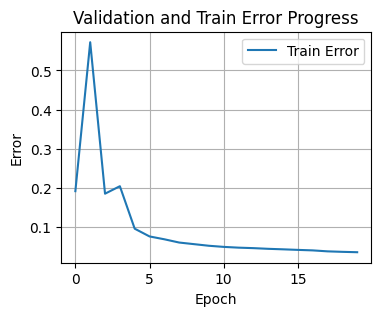

Perceptron error: 0
MAE error: 0.1372623972612457
MSE error: 0.036555735293740343


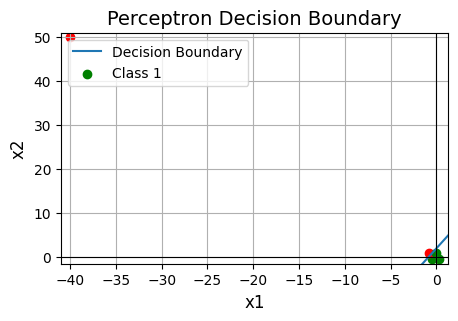

,Input,Predicted,True
0,"[-0.5, -0.5]",[0.9045625729076306],1
1,"[0.3, -0.5]",[0.9981937904753418],1
2,"[-40.0, 50.0]",[-1.0],-1
3,"[-0.8, 1.0]",[-0.7145858932215945],-1
4,"[-0.1, 1.0]",[0.6963457570892045],1


In [182]:
# Data and parameters:
inputs, true_outputs = example_outliers()
data_description = "Out"

print_progress = True
activation = 'tanh'
learning_rate = 0.8
init_method = 'random'
adaptive_learning_rate = True
min_error = 0.0001
epochs = 20

# Train the linear neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
# perceptron.set_weights(np.array([10000, 10000]), 10000) # set weights to large values
training_errors, validation_errors = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress=print_progress)
# Print summary:
print(perceptron)
plot_error_progress(training_errors, validation_errors)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
error = perceptron_error(true_outputs, real_outputs)
print(f"Perceptron error: {error}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df


- Run the same example with normalization
- In this case, blind normalization leads to worse results.

Gradient Descent iterative:
Epoch: 0, MSE: 0.7583 Weights: [[ 1.86135538 -1.97156009]] Bias: -1.8232758708446517 Learning rate: 2.0000
Epoch: 1, MSE: 0.7533 Weights: [[ 1.59536584 -1.70720732]] Bias: -1.3850701348101062 Learning rate: 1.4142
Epoch: 2, MSE: 1.9653 Weights: [[ 1.4006528  -1.51341052]] Bias: -3.9779303403212625 Learning rate: 1.1547
Epoch: 3, MSE: 0.7987 Weights: [[ 3.22724031 -3.36806756]] Bias: -2.6796474581557574 Learning rate: 1.0000
Epoch: 4, MSE: 0.7323 Weights: [[ 3.2209291  -3.36178848]] Bias: -4.674814866066906 Learning rate: 0.8944
Epoch: 5, MSE: 0.7918 Weights: [[ 4.02796932 -4.12861387]] Bias: -5.061713203533649 Learning rate: 0.8165
Epoch: 6, MSE: 0.7010 Weights: [[ 4.06815038 -4.16703736]] Bias: -6.4439369824168615 Learning rate: 0.7559
Epoch: 7, MSE: 0.7741 Weights: [[ 4.65100099 -4.78574953]] Bias: -6.85329158090363 Learning rate: 0.7071
Epoch: 8, MSE: 0.5033 Weights: [[ 4.57306791 -4.708205  ]] Bias: -8.210259616242535 Learning rate: 0.6667
Epoch: 9, MSE:

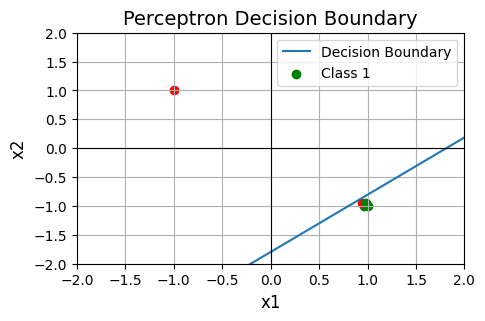

,Input,Predicted,True
0,"[0.9602977667493797, -1.0]",[0.826349903130652],1
1,"[1.0, -1.0]",[0.9004745052924855],1
2,"[-1.0, 1.0]",[-1.0],-1
3,"[0.9454094292803974, -0.9405940594059405]",[0.5473504406158413],-1
4,"[0.9801488833746899, -0.9405940594059405]",[0.7041684225931497],1


In [183]:
# Data and parameters:
inputs, true_outputs = example_normalized_outliers()
# inputs, true_outputs = example_std_normalized_outliers()
data_description = "Out"

print_progress = True
activation = 'tanh'
learning_rate = 2
init_method = 'random'
adaptive_learning_rate = True
min_error = 0.0001
epochs = 50

# Train the linear neuron:
perceptron = Perceptron(inputs.shape[1], activation, init_method)
# perceptron.set_weights(np.array([10000, 10000]), 10000) # set weights to large values
perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress=print_progress)
# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
error = perceptron_error(true_outputs, real_outputs)
print(f"Perceptron error: {error}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
plot_decision_boundary_2D(perceptron, inputs, true_outputs)

# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs), 'True': label}
df